Week 2 – Deliverable 3: Data Cleaning using Python

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("../data/raw/Hotel_Reviews.csv")

In [6]:
df.head()
print("------------------------------")
df.info()
print("------------------------------")
df.shape
print("------------------------------")
df.columns

------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   Hotel_Address                               515738 non-null  str    
 1   Additional_Number_of_Scoring                515738 non-null  int64  
 2   Review_Date                                 515738 non-null  str    
 3   Average_Score                               515738 non-null  float64
 4   Hotel_Name                                  515738 non-null  str    
 5   Reviewer_Nationality                        515738 non-null  str    
 6   Negative_Review                             515738 non-null  str    
 7   Review_Total_Negative_Word_Counts           515738 non-null  int64  
 8   Total_Number_of_Reviews                     515738 non-null  int64  
 9   Positive_Review                             515738

Index(['Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date',
       'Average_Score', 'Hotel_Name', 'Reviewer_Nationality',
       'Negative_Review', 'Review_Total_Negative_Word_Counts',
       'Total_Number_of_Reviews', 'Positive_Review',
       'Review_Total_Positive_Word_Counts',
       'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score', 'Tags',
       'days_since_review', 'lat', 'lng'],
      dtype='str')

In [7]:
df.isnull().sum()

Hotel_Address                                    0
Additional_Number_of_Scoring                     0
Review_Date                                      0
Average_Score                                    0
Hotel_Name                                       0
Reviewer_Nationality                             0
Negative_Review                                  0
Review_Total_Negative_Word_Counts                0
Total_Number_of_Reviews                          0
Positive_Review                                  0
Review_Total_Positive_Word_Counts                0
Total_Number_of_Reviews_Reviewer_Has_Given       0
Reviewer_Score                                   0
Tags                                             0
days_since_review                                0
lat                                           3268
lng                                           3268
dtype: int64

In [8]:
missing = (df.isnull().sum() / len(df)) * 100
missing.sort_values(ascending=False)

lng                                           0.633655
lat                                           0.633655
Hotel_Address                                 0.000000
Additional_Number_of_Scoring                  0.000000
Review_Date                                   0.000000
Reviewer_Nationality                          0.000000
Negative_Review                               0.000000
Average_Score                                 0.000000
Hotel_Name                                    0.000000
Total_Number_of_Reviews                       0.000000
Review_Total_Negative_Word_Counts             0.000000
Positive_Review                               0.000000
Review_Total_Positive_Word_Counts             0.000000
Reviewer_Score                                0.000000
Total_Number_of_Reviews_Reviewer_Has_Given    0.000000
days_since_review                             0.000000
Tags                                          0.000000
dtype: float64

In [9]:
df.duplicated().sum()

np.int64(526)

In [10]:
df = df.drop_duplicates()

In [11]:
df["Review_Date"] = pd.to_datetime(df["Review_Date"])

In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 515212 entries, 0 to 515737
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   Hotel_Address                               515212 non-null  str           
 1   Additional_Number_of_Scoring                515212 non-null  int64         
 2   Review_Date                                 515212 non-null  datetime64[us]
 3   Average_Score                               515212 non-null  float64       
 4   Hotel_Name                                  515212 non-null  str           
 5   Reviewer_Nationality                        515212 non-null  str           
 6   Negative_Review                             515212 non-null  str           
 7   Review_Total_Negative_Word_Counts           515212 non-null  int64         
 8   Total_Number_of_Reviews                     515212 non-null  int64         
 9   Positive_

In [13]:
df[["lat", "lng"]].isnull().sum()

lat    3268
lng    3268
dtype: int64

In [14]:
df = df.dropna(subset=["lat", "lng"])

In [15]:
df.isnull().sum()

Hotel_Address                                 0
Additional_Number_of_Scoring                  0
Review_Date                                   0
Average_Score                                 0
Hotel_Name                                    0
Reviewer_Nationality                          0
Negative_Review                               0
Review_Total_Negative_Word_Counts             0
Total_Number_of_Reviews                       0
Positive_Review                               0
Review_Total_Positive_Word_Counts             0
Total_Number_of_Reviews_Reviewer_Has_Given    0
Reviewer_Score                                0
Tags                                          0
days_since_review                             0
lat                                           0
lng                                           0
dtype: int64

In [16]:
df.shape

(511944, 17)

In [17]:
df.to_csv("../data/processed/hotel_reviews_cleaned.csv", index=False)

Week 2- Deliverable 4: EDA

In [18]:
df.describe()

,Additional_Number_of_Scoring,Review_Date,Average_Score,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,lat,lng
count,511944.000000,511944,511944.000000,511944.000000,511944.000000,511944.000000,511944.000000,511944.000000,511944.000000,511944.000000
mean,500.456802,2016-08-13 15:21:56.056443,8.398216,18.543247,2748.469807,17.766849,7.151145,8.396053,49.443040,2.824222
min,1.000000,2015-08-04 00:00:00,5.200000,0.000000,43.000000,0.000000,1.000000,2.500000,41.328376,-0.369758
25%,169.000000,2016-02-23 00:00:00,8.100000,2.000000,1161.000000,5.000000,1.000000,7.500000,48.214277,-0.143649
50%,343.000000,2016-08-15 00:00:00,8.400000,9.000000,2134.000000,11.000000,3.000000,8.800000,51.499981,-0.000250
75%,666.000000,2017-02-09 00:00:00,8.800000,23.000000,3633.000000,22.000000,8.000000,9.600000,51.516288,4.834443
max,2682.000000,2017-08-03 00:00:00,9.800000,408.000000,16670.000000,395.000000,355.000000,10.000000,52.400181,16.429233
std,501.549523,NaN,0.549038,29.696878,2323.330791,21.789369,11.028050,1.637778,3.468029,4.581637


In [19]:
df.describe(include='object')

C:\Users\juhik\AppData\Local\Temp\ipykernel_21372\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Hotel_Address,Hotel_Name,Reviewer_Nationality,Negative_Review,Positive_Review,Tags,days_since_review
count,511944,511944,511944,511944,511944,511944,511944
unique,1476,1475,227,327927,409941,54934,731
top,163 Marsh Wall Docklands Tower Hamlets London ...,Britannia International Hotel Canary Wharf,United Kingdom,No Negative,No Positive,"[' Leisure trip ', ' Couple ', ' Double Room '...",1 days
freq,4789,4789,244321,126902,35695,5100,2583


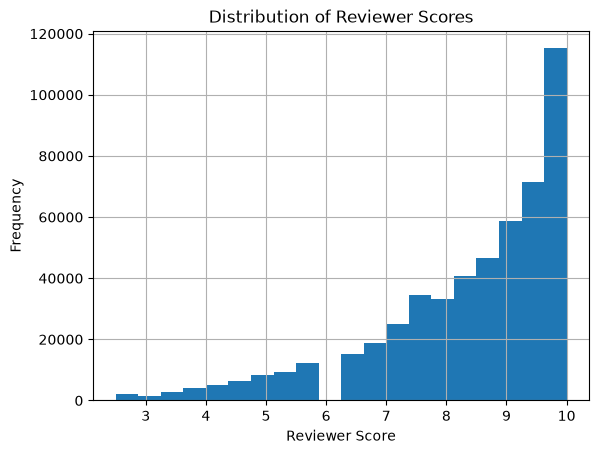

In [21]:
#reviewer score distribution

import matplotlib.pyplot as plt

df["Reviewer_Score"].hist(bins=20)
plt.title("Distribution of Reviewer Scores")
plt.xlabel("Reviewer Score")
plt.ylabel("Frequency")
plt.show()

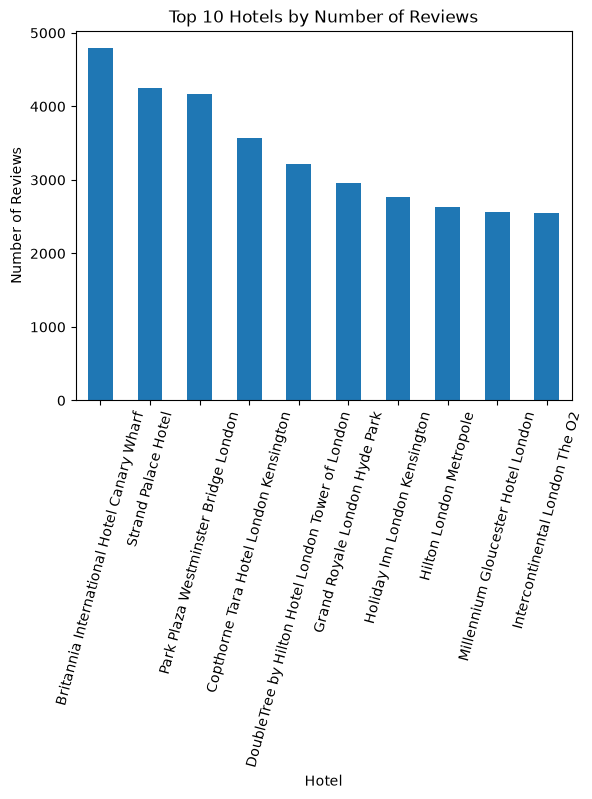

In [22]:
#top 10 hotels by number of reviews

top_hotels = df["Hotel_Name"].value_counts().head(10)

top_hotels.plot(kind="bar")
plt.title("Top 10 Hotels by Number of Reviews")
plt.xlabel("Hotel")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=75)
plt.show()

In [25]:
#reviewer nationality distribution

df["Reviewer_Nationality"].value_counts().head(10)



Reviewer_Nationality
United Kingdom               244321
United States of America      35108
Australia                     21502
Ireland                       14733
United Arab Emirates          10170
Saudi Arabia                   8903
Netherlands                    8691
Switzerland                    8607
Germany                        7831
Canada                         7802
Name: count, dtype: int64

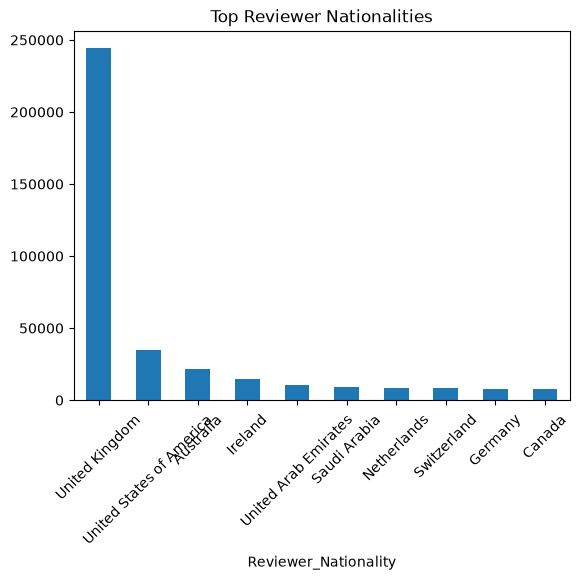

In [26]:
df["Reviewer_Nationality"].value_counts().head(10).plot(kind="bar")
plt.title("Top Reviewer Nationalities")
plt.xticks(rotation=45)
plt.show()

In [27]:
#average hotel ratings

hotel_scores = (
    df.groupby("Hotel_Name")["Reviewer_Score"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

hotel_scores

Hotel_Name
Ritz Paris                             9.725000
Hotel Casa Camper                      9.718937
41                                     9.711650
H tel de La Tamise Esprit de France    9.688525
Le Narcisse Blanc Spa                  9.671930
H10 Casa Mimosa 4 Sup                  9.660345
Hotel Eiffel Blomet                    9.646667
Hotel The Serras                       9.623474
45 Park Lane Dorchester Collection     9.603571
The Soho Hotel                         9.597452
Name: Reviewer_Score, dtype: float64

In [28]:
#correlation matrix

numeric = df.select_dtypes(include=["int64", "float64"])

numeric.corr()

,Additional_Number_of_Scoring,Average_Score,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,lat,lng
Additional_Number_of_Scoring,1.000000,-0.154171,0.029208,0.825228,-0.053025,-0.071675,-0.062177,0.336270,-0.295876
Average_Score,-0.154171,1.000000,-0.112663,-0.180215,0.106912,0.036932,0.364791,-0.108804,0.106100
Review_Total_Negative_Word_Counts,0.029208,-0.112663,1.000000,0.035129,0.119196,0.003030,-0.382653,0.019116,-0.020012
Total_Number_of_Reviews,0.825228,-0.180215,0.035129,1.000000,-0.029981,-0.024992,-0.073137,0.100262,-0.014200
Review_Total_Positive_Word_Counts,-0.053025,0.106912,0.119196,-0.029981,1.000000,0.026489,0.220643,-0.037590,0.035475
Total_Number_of_Reviews_Reviewer_Has_Given,-0.071675,0.036932,0.003030,-0.024992,0.026489,1.000000,0.002997,-0.059805,0.110855
Reviewer_Score,-0.062177,0.364791,-0.382653,-0.073137,0.220643,0.002997,1.000000,-0.036644,0.033989
lat,0.336270,-0.108804,0.019116,0.100262,-0.037590,-0.059805,-0.036644,1.000000,-0.304546
lng,-0.295876,0.106100,-0.020012,-0.014200,0.035475,0.110855,0.033989,-0.304546,1.000000


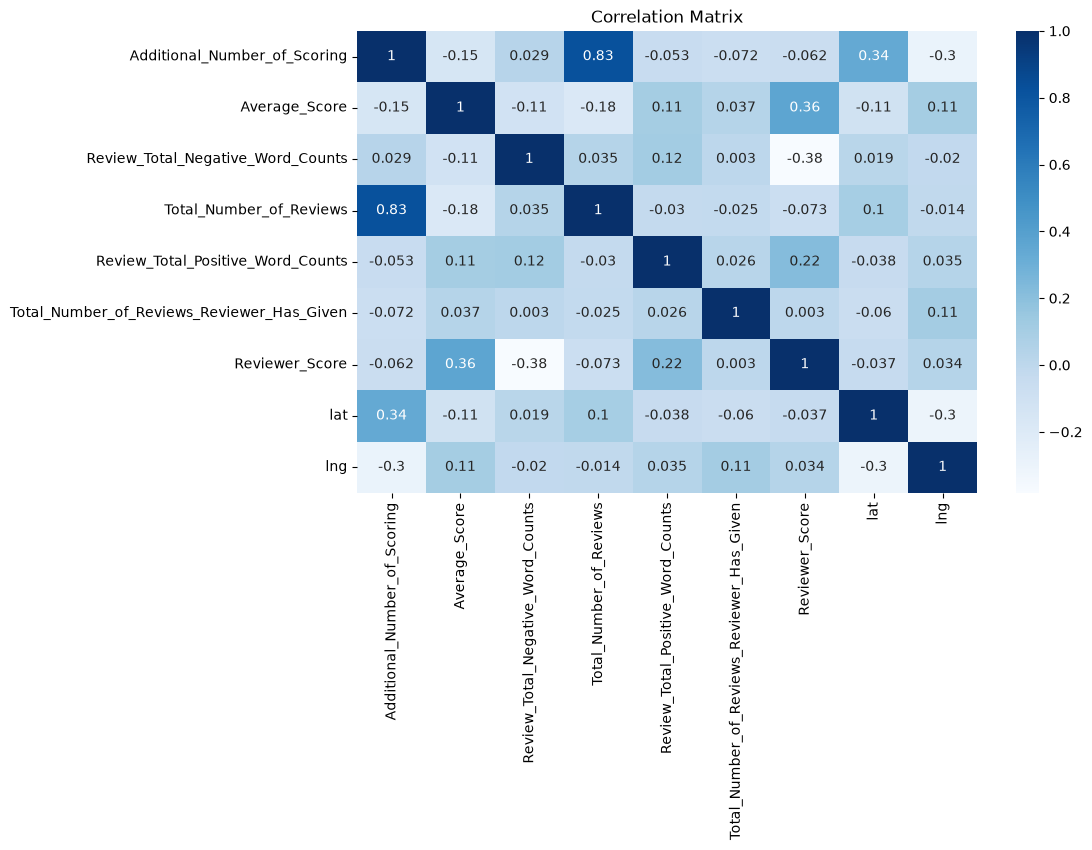

In [30]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(numeric.corr(), annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

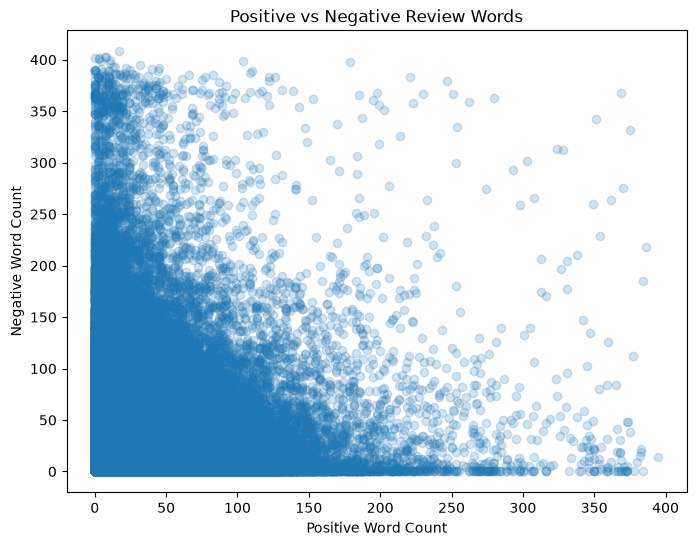

In [31]:
#postive vs negative reviews

plt.figure(figsize=(8,6))

plt.scatter(
    df["Review_Total_Positive_Word_Counts"],
    df["Review_Total_Negative_Word_Counts"],
    alpha=0.2
)

plt.xlabel("Positive Word Count")
plt.ylabel("Negative Word Count")
plt.title("Positive vs Negative Review Words")
plt.show()

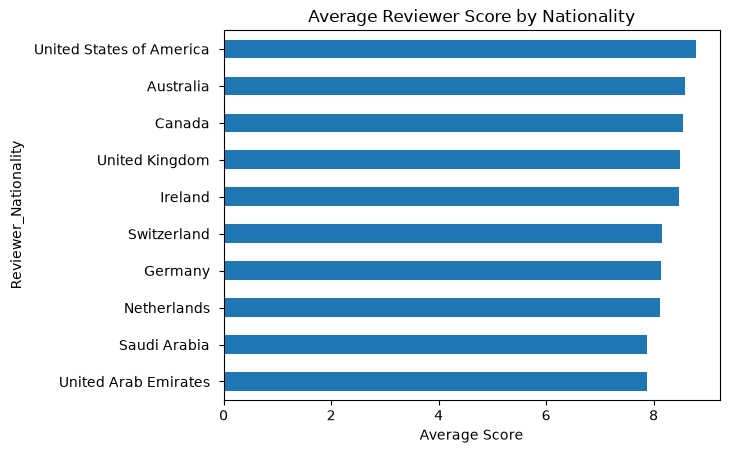

In [32]:
#avg reviewer score by nationality

top10 = df["Reviewer_Nationality"].value_counts().head(10).index

avg_score = (
    df[df["Reviewer_Nationality"].isin(top10)]
    .groupby("Reviewer_Nationality")["Reviewer_Score"]
    .mean()
    .sort_values()
)

avg_score.plot(kind="barh")

plt.title("Average Reviewer Score by Nationality")
plt.xlabel("Average Score")
plt.show()